In [2]:
import numpy as np
from utils.data import generate_data
from utils.select_lib import get_proba, classifier
from utils.plot import plot_2D

In [3]:
params = {
    "n_classes": 2,
    "n_samples": 100000,
    "means": [[-1, -1], [1, 1]],
    "covs": [np.eye(2), np.eye(2)],
    "priors": [0.3, 0.7],
    "seed": 42,
}


def classifier_pipeline(params: dict):

    data, labels = generate_data(**params)

    plot_2D(data, labels, figsize=(6, 6))

    prob = get_proba(data, **params)
    pred, confidence = classifier(prob)

    return data, labels, pred, confidence

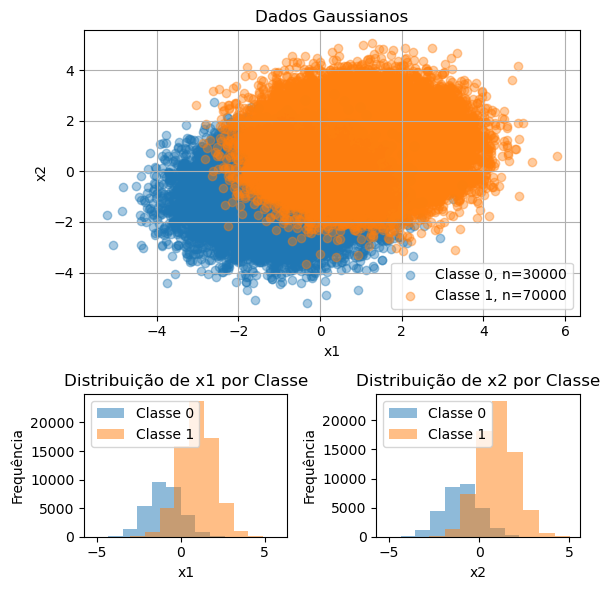

In [4]:
data, labels, pred, confidence = classifier_pipeline(params)

index = np.argsort(confidence)[::-1]
confidence = confidence[index]
labels = labels[index]
pred = pred[index]
data = data[index]

In [ ]:
# classe 0
def get_class_k(data, labels, pred, confidence, k):
    idx_k = np.where(labels == k)[0]
    labels_k = labels[idx_k]
    pred_k = pred[idx_k]
    confidence_k = confidence[idx_k]
    data_k = data[idx_k]
    return data_k, labels_k, pred_k, confidence_k


def tau_k(confidence_0, pred_0, labels_0, lam, pi_0):
    objectives = []
    for tau_k in confidence_0:
        mask_k = confidence_0 >= tau_k
        cover_k = np.mean(mask_k)
        risk_k = np.mean(pred_0[mask_k] != labels_0[mask_k])
        tao_k = risk_k - lam * pi_0 * cover_k
        objectives.append(tao_k)
    tau_0_star = confidence_0[np.argmin(objectives)]
    return tau_0_star

In [ ]:
goal_cover = 0.8
cover_tau_0 = 1.0
lam_low = 0.001
lam_high = 5


epsilon = 0.01

# dados
pi_0 = params["priors"][0]
pi_1 = params["priors"][1]

data_0, labels_0, pred_0, confidence_0 = get_class_k(
    data, labels, pred, confidence, k=0
)
data_1, labels_1, pred_1, confidence_1 = get_class_k(
    data, labels, pred, confidence, k=1
)

In [ ]:
kappa = 0.1

while abs(kappa - goal_cover) > epsilon:

    lam_mid = (lam_low + lam_high) / 2

    tao_0 = tau_k(confidence_0, pred_0, labels_0, lam_mid, pi_0)
    tao_1 = tau_k(confidence_1, pred_1, labels_1, lam_mid, pi_1)

    tao_0_cover = np.mean(confidence_0 >= tao_0)
    tao_1_cover = np.mean(confidence_1 >= tao_1)
    kappa = pi_0 * tao_0_cover + pi_1 * tao_1_cover
    print(
        f"lambda: {lam_mid:.4f}, kappa: {kappa:.4f}, tao_0: {tao_0:.4f}, tao_1: {tao_1:.4f}"
    )

    if kappa < goal_cover:
        lam_low = lam_mid

    elif kappa > goal_cover:
        lam_high = lam_mid


print("Goal cover reached!")
print(
    f"lambda: {lam_mid:.4f}, kappa: {kappa:.4f}, tao_0: {tao_0:.4f}, tao_1: {tao_1:.4f}"
)

lambda: 2.5005, kappa: 1.0000, tao_0: 0.5001, tao_1: 0.5001
lambda: 1.2508, kappa: 0.9995, tao_0: 0.5021, tao_1: 0.5001
lambda: 0.6259, kappa: 0.9077, tao_0: 0.8565, tao_1: 0.5495
lambda: 0.3134, kappa: 0.8024, tao_0: 0.9561, tao_1: 0.7511
Goal cover reached!
lambda: 0.1572, kappa: 0.8024, tao_0: 0.9561, tao_1: 0.7511


In [ ]:
tao_0_cover = np.mean(confidence_0 >= tao_0)
tao_1_cover = np.mean(confidence_1 >= tao_1)

print(f"tau_0: {tao_0:.4f}, cover: {tao_0_cover:.4f}")
print(f"tau_1: {tao_1:.4f}, cover: {tao_1_cover:.4f}")

tau_1: 0.9996, cover: 0.0470
tau_2: 0.9970, cover: 0.1737
